# Remote-POMDP API parameter grid

This notebook runs alternating person-by-person optimization on one fixed EffCom-style control MDP while varying $\beta$, $\gamma$, and the erasure probability $\epsilon$. It focuses on reachable revealing violations and compares the results with the theoretical surface

$$m(\beta,\gamma,\epsilon)=\beta-\frac{\gamma\epsilon(1-\epsilon)}{1-\gamma}=0.$$


## Experimental design

The same sampled MDP, uniform initial distribution, and deterministic initialization are used at every grid point. The grid has 96 runs. Results are written incrementally to results.json, so an interrupted computation can be resumed. All reported objectives and regrets use exact discounted Bellman policy evaluation rather than rollout estimates.


In [1]:
from __future__ import annotations

import json
import multiprocessing as mp
import os
import sys
import time
import traceback
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/remote_pomdp_mpl")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm, Normalize

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "remote_api.py").exists()
)
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "api_grid_s10_d05_delta100"
RESULTS_PATH = EXPERIMENT_DIR / "results.json"
sys.path.insert(0, str(PROJECT_ROOT))

from mdp import create_effcom_control_family, initial_distribution, select_density
from remote_api import SolverConfig, run_api

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (9.5, 5.8),
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
})
print(f"Project root: {PROJECT_ROOT}")
print(f"Experiment directory: {EXPERIMENT_DIR}")


Project root: /Users/rplanchon/Documents/Etudes/MVA/Stage/Imperial/work/RemotePOMDP
Experiment directory: /Users/rplanchon/Documents/Etudes/MVA/Stage/Imperial/work/RemotePOMDP/experiments/api_grid_s10_d05_delta100


In [2]:
GAMMAS = np.array([0.80, 0.90, 0.95])
EPSILONS = np.array([0.05, 0.10, 0.20, 0.30])
BETAS = np.array([0.05, 0.10, 0.20, 0.40, 0.80, 1.20, 2.00, 4.20])

N_STATES = 10
N_ACTIONS = 2
DENSITY = 0.5
DELTA_MAX = 100
SEED = 12
MAX_WORKERS = 3

VI_TOL = 1e-10
RX_ACCEPT_TOL = 1e-9
API_TOL = 1e-9
NE_TOL = 1e-8
MARGIN_TOL = 1e-10
TIE_TOL = 1e-12

GRID = [
    (float(beta), float(gamma), float(epsilon))
    for gamma in GAMMAS
    for epsilon in EPSILONS
    for beta in BETAS
]
assert len(GRID) == 96
assert all(epsilon > 0.0 for _, _, epsilon in GRID)
print(f"Grid size: {len(GRID)} runs")


Grid size: 96 runs


In [3]:
family = create_effcom_control_family(
    n_states=N_STATES, n_actions=N_ACTIONS, seed=SEED
)
mdp = select_density(family, DENSITY)
mu0 = initial_distribution(N_STATES)
support_sizes = np.count_nonzero(mdp.P > 0.0, axis=2)

print(f"Selected density: {mdp.density}")
print(f"Successors per (action, state): {np.unique(support_sizes).tolist()}")
print(f"Reward range: [{mdp.R.min():.6g}, {mdp.R.max():.6g}]")
print(f"Optimal-state index in the generator: {mdp.optimal_state}")
print(f"mu0: {mu0.tolist()}")


Selected density: 0.5
Successors per (action, state): [5]
Reward range: [8.75651e-27, 1]
Optimal-state index in the generator: 6
mu0: [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]


## Run or resume the grid

Each worker regenerates the same small MDP from the fixed seed, runs API, and returns a compact record. The parent process updates results.json as runs finish.


In [4]:
def run_key(beta: float, gamma: float, epsilon: float) -> str:
    return f"beta={beta:.12g}|gamma={gamma:.12g}|epsilon={epsilon:.12g}"


def run_grid_point(parameters: tuple[float, float, float]) -> dict:
    beta, gamma, epsilon = parameters
    started = time.perf_counter()
    try:
        local_mdp = select_density(
            create_effcom_control_family(
                n_states=N_STATES, n_actions=N_ACTIONS, seed=SEED
            ),
            DENSITY,
        )
        config = SolverConfig(
            gamma=gamma,
            beta=beta,
            epsilon=epsilon,
            delta_max=DELTA_MAX,
            vi_tol=VI_TOL,
            rx_accept_tol=RX_ACCEPT_TOL,
            api_tol=API_TOL,
            ne_tol=NE_TOL,
            margin_tol=MARGIN_TOL,
            tie_tol=TIE_TOL,
        )
        result = run_api(
            local_mdp,
            config,
            mu0=initial_distribution(N_STATES),
            seed=SEED,
            compute_lower_bound=False,
        )
        final_step = result.history[-1] if result.history else {}
        if final_step and not final_step["tx_changed"] and not final_step["rx_changed"]:
            stop_reason = "policies_unchanged"
        elif final_step and abs(float(final_step["improvement"])) <= API_TOL:
            stop_reason = "api_tolerance"
        elif result.api_iterations >= config.max_api_iterations:
            stop_reason = "iteration_cap"
        else:
            stop_reason = "other"

        violation_history = [
            {
                "api_iteration": int(item["api_iteration"]),
                "violation_count": int(item["revealing_violation_count"]),
            }
            for item in result.violation_history
        ]
        objective_history = [
            {
                "api_iteration": 0,
                "objective": float(result.diagnostics["initial_objective"]),
                "improvement": None,
            }
        ] + [
            {
                "api_iteration": int(item["api_iteration"]),
                "objective": float(item["objective"]),
                "improvement": float(item["improvement"]),
            }
            for item in result.history
        ]
        return {
            "key": run_key(beta, gamma, epsilon),
            "status": "ok",
            "beta": beta,
            "gamma": gamma,
            "epsilon": epsilon,
            "margin": float(config.theorem_margin),
            "margin_region": config.margin_region,
            "objective": float(result.objective),
            "lower_bound_objective": (
                None if result.lower_bound_objective is None
                else float(result.lower_bound_objective)
            ),
            "tx_regret": float(result.tx_regret),
            "rx_restricted_regret": float(result.rx_restricted_regret),
            "approximate_restricted_ne": bool(result.approximate_restricted_ne),
            "api_converged": bool(result.converged),
            "api_iterations": int(result.api_iterations),
            "api_stop_reason": stop_reason,
            "final_abs_improvement": (
                None if not final_step else abs(float(final_step["improvement"]))
            ),
            "violation_count": int(len(result.revealing.violations)),
            "violating_states": result.revealing.violations,
            "boundary_transmission_count": int(
                len(result.revealing.boundary_transmissions)
            ),
            "reachable_statistics": result.revealing.statistics,
            "violation_history": violation_history,
            "objective_history": objective_history,
            "elapsed_seconds": float(time.perf_counter() - started),
        }
    except Exception as exc:
        return {
            "key": run_key(beta, gamma, epsilon),
            "status": "error",
            "beta": beta,
            "gamma": gamma,
            "epsilon": epsilon,
            "error_type": type(exc).__name__,
            "error": str(exc),
            "traceback": traceback.format_exc(),
            "elapsed_seconds": float(time.perf_counter() - started),
        }


def experiment_metadata() -> dict:
    return {
        "description": "Remote-POMDP API Cartesian parameter grid",
        "n_states": N_STATES,
        "n_actions": N_ACTIONS,
        "density": DENSITY,
        "delta_max": DELTA_MAX,
        "seed": SEED,
        "mu0": initial_distribution(N_STATES).tolist(),
        "gammas": GAMMAS.tolist(),
        "epsilons": EPSILONS.tolist(),
        "betas": BETAS.tolist(),
        "grid_size": len(GRID),
        "tolerances": {
            "vi_tol": VI_TOL,
            "rx_accept_tol": RX_ACCEPT_TOL,
            "api_tol": API_TOL,
            "ne_tol": NE_TOL,
            "margin_tol": MARGIN_TOL,
            "tie_tol": TIE_TOL,
        },
    }


def save_results(records: dict[str, dict]) -> None:
    payload = {
        "metadata": experiment_metadata(),
        "runs": sorted(
            records.values(),
            key=lambda item: (item["gamma"], item["epsilon"], item["beta"]),
        ),
    }
    temporary_path = RESULTS_PATH.with_suffix(".json.tmp")
    temporary_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    temporary_path.replace(RESULTS_PATH)


In [5]:
if RESULTS_PATH.exists():
    cached_payload = json.loads(RESULTS_PATH.read_text(encoding="utf-8"))
    records = {item["key"]: item for item in cached_payload.get("runs", [])}
else:
    records = {}

pending = [
    parameters for parameters in GRID
    if records.get(run_key(*parameters), {}).get("status") != "ok"
]
print(f"Cached successful runs: {len(GRID) - len(pending)}/{len(GRID)}")

if pending:
    start_method = "fork" if "fork" in mp.get_all_start_methods() else None
    executor_kwargs = {"max_workers": MAX_WORKERS}
    if start_method is not None:
        executor_kwargs["mp_context"] = mp.get_context(start_method)
    started = time.perf_counter()
    with ProcessPoolExecutor(**executor_kwargs) as executor:
        futures = {executor.submit(run_grid_point, item): item for item in pending}
        for completed_count, future in enumerate(as_completed(futures), start=1):
            record = future.result()
            records[record["key"]] = record
            save_results(records)
            if completed_count == 1 or completed_count % 8 == 0 or completed_count == len(pending):
                elapsed = time.perf_counter() - started
                print(
                    f"Completed {completed_count}/{len(pending)} pending runs "
                    f"({elapsed / 60:.1f} min); latest status={record['status']}"
                )

payload = json.loads(RESULTS_PATH.read_text(encoding="utf-8"))
runs = payload["runs"]
successful_runs = [item for item in runs if item["status"] == "ok"]
failed_runs = [item for item in runs if item["status"] != "ok"]
print(f"Successful runs: {len(successful_runs)}/{len(GRID)}")
print(f"Failed runs: {len(failed_runs)}")


Cached successful runs: 96/96
Successful runs: 96/96
Failed runs: 0


## Numerical checks and compact results table


In [6]:
df = pd.DataFrame(successful_runs).sort_values(
    ["gamma", "epsilon", "beta"]
).reset_index(drop=True)
df["max_restricted_regret"] = df[["tx_regret", "rx_restricted_regret"]].max(axis=1)
df["peak_training_violations"] = df["violation_history"].map(
    lambda history: max(item["violation_count"] for item in history)
)
df["api_margin_ratio"] = np.where(
    np.abs(df["margin"]) > MARGIN_TOL,
    API_TOL / np.abs(df["margin"]),
    np.nan,
)

print(f"API converged: {int(df.api_converged.sum())}/{len(df)}")
print(f"Approximate restricted NE: {int(df.approximate_restricted_ne.sum())}/{len(df)}")
print(f"Runs with final violations: {int((df.violation_count > 0).sum())}/{len(df)}")
print("API stopping reasons:")
print(df.api_stop_reason.value_counts().to_string())

columns = [
    "beta", "gamma", "epsilon", "margin", "objective",
    "violation_count", "api_iterations", "api_stop_reason",
    "max_restricted_regret",
]
print("\nFirst eight grid records:")
print(df[columns].head(8).to_string(index=False))


API converged: 96/96
Approximate restricted NE: 96/96
Runs with final violations: 45/96
API stopping reasons:
api_stop_reason
policies_unchanged    83
api_tolerance         13

First eight grid records:
 beta  gamma  epsilon  margin  objective  violation_count  api_iterations    api_stop_reason  max_restricted_regret
 0.05    0.8     0.05   -0.14   0.679058                0               2 policies_unchanged                    0.0
 0.10    0.8     0.05   -0.09   0.620291                0               2 policies_unchanged                    0.0
 0.20    0.8     0.05    0.01   0.522675                0               2 policies_unchanged                    0.0
 0.40    0.8     0.05    0.21   0.404891                0               2 policies_unchanged                    0.0
 0.80    0.8     0.05    0.61   0.399125                0               2      api_tolerance                    0.0
 1.20    0.8     0.05    1.01   0.399125                0               2      api_tolerance         

## 3D grid and the theoretical surface

Drag to rotate the Plotly scene; use the mouse wheel to zoom and hover over points for the exact parameters, margin, objective, and violation count. Hollow points have zero final violations. Filled points have violations; their color intensity uses a logarithmic normalization so small and large positive counts remain distinguishable. The colorbar labels are the actual counts.


In [13]:
try:
    from IPython.display import HTML as IPythonHTML
except ImportError:
    IPythonHTML = None

gamma_surface = np.linspace(GAMMAS.min(), GAMMAS.max(), 80)
epsilon_surface = np.linspace(EPSILONS.min(), EPSILONS.max(), 80)
G, E = np.meshgrid(gamma_surface, epsilon_surface)
B0 = G * E * (1.0 - E) / (1.0 - G)

zero = df[df.violation_count == 0]
positive = df[df.violation_count > 0]
traces = [{
    "type": "surface",
    "name": "Theoretical m=0",
    "x": G.tolist(),
    "y": E.tolist(),
    "z": B0.tolist(),
    "surfacecolor": np.zeros_like(B0).tolist(),
    "colorscale": [[0, "#f28e2b"], [1, "#f28e2b"]],
    "showscale": False,
    "opacity": 0.28,
    "hovertemplate": "gamma=%{x:.3f}<br>epsilon=%{y:.3f}<br>beta at m=0=%{z:.3f}<extra>Theoretical m=0</extra>",
}]
traces.append({
    "type": "scatter3d",
    "mode": "markers",
    "name": "0 violations",
    "x": zero.gamma.tolist(),
    "y": zero.epsilon.tolist(),
    "z": zero.beta.tolist(),
    "customdata": np.column_stack([zero.margin, zero.objective]).tolist(),
    "marker": {"size": 5, "symbol": "circle-open", "color": "#202020", "line": {"width": 2}},
    "hovertemplate": "gamma=%{x:.2f}<br>epsilon=%{y:.2f}<br>beta=%{z:.2f}<br>violations=0<br>m=%{customdata[0]:.4g}<br>J=%{customdata[1]:.6g}<extra></extra>",
})
if not positive.empty:
    maximum = int(positive.violation_count.max())
    color_ticks = sorted(set([value for value in [1, 10, 100, maximum] if value <= maximum]))
    traces.append({
        "type": "scatter3d",
        "mode": "markers",
        "name": ">0 violations",
        "x": positive.gamma.tolist(),
        "y": positive.epsilon.tolist(),
        "z": positive.beta.tolist(),
        "customdata": np.column_stack([positive.violation_count, positive.margin, positive.objective]).tolist(),
        "marker": {
            "size": 6,
            "color": np.log10(positive.violation_count).tolist(),
            "colorscale": "Viridis",
            "cmin": 0,
            "cmax": float(np.log10(maximum)),
            "line": {"color": "#202020", "width": 0.5},
            "colorbar": {
                "title": {"text": "Final violations"},
                "tickvals": np.log10(color_ticks).tolist(),
                "ticktext": [str(value) for value in color_ticks],
            },
        },
        "hovertemplate": "gamma=%{x:.2f}<br>epsilon=%{y:.2f}<br>beta=%{z:.2f}<br>violations=%{customdata[0]:.0f}<br>m=%{customdata[1]:.4g}<br>J=%{customdata[2]:.6g}<extra></extra>",
    })

layout = {
    "title": {"text": "API grid: final violations and theoretical m=0 surface", "x": 0.5},
    "template": "plotly_white",
    "height": 720,
    "margin": {"l": 0, "r": 20, "b": 0, "t": 55},
    "legend": {"x": 0.01, "y": 0.99},
    "scene": {
        "xaxis": {"title": "Discount gamma"},
        "yaxis": {"title": "Erasure probability epsilon"},
        "zaxis": {"title": "Communication cost beta"},
        "camera": {"eye": {"x": 1.45, "y": -1.55, "z": 1.05}},
    },
}
plotly_html = f"""
<div id="api-grid-3d-plotly" style="width:100%;height:720px;"></div>
<script src="https://cdn.jsdelivr.net/npm/plotly.js-dist-min@2.35.2/plotly.min.js"></script>
<script>
(function() {{
  const element = document.getElementById("api-grid-3d-plotly");
  Plotly.newPlot(element, {json.dumps(traces)}, {json.dumps(layout)}, {{responsive: true, displaylogo: false}});
}})();
</script>
"""
plotly_result = IPythonHTML(plotly_html) if IPythonHTML is not None else plotly_html
plotly_result


## Violation heatmaps

Each panel is one discount factor. Cell labels are exact final counts, and the orange curve is the corresponding theoretical $m=0$ boundary.


notebook_cell_13:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


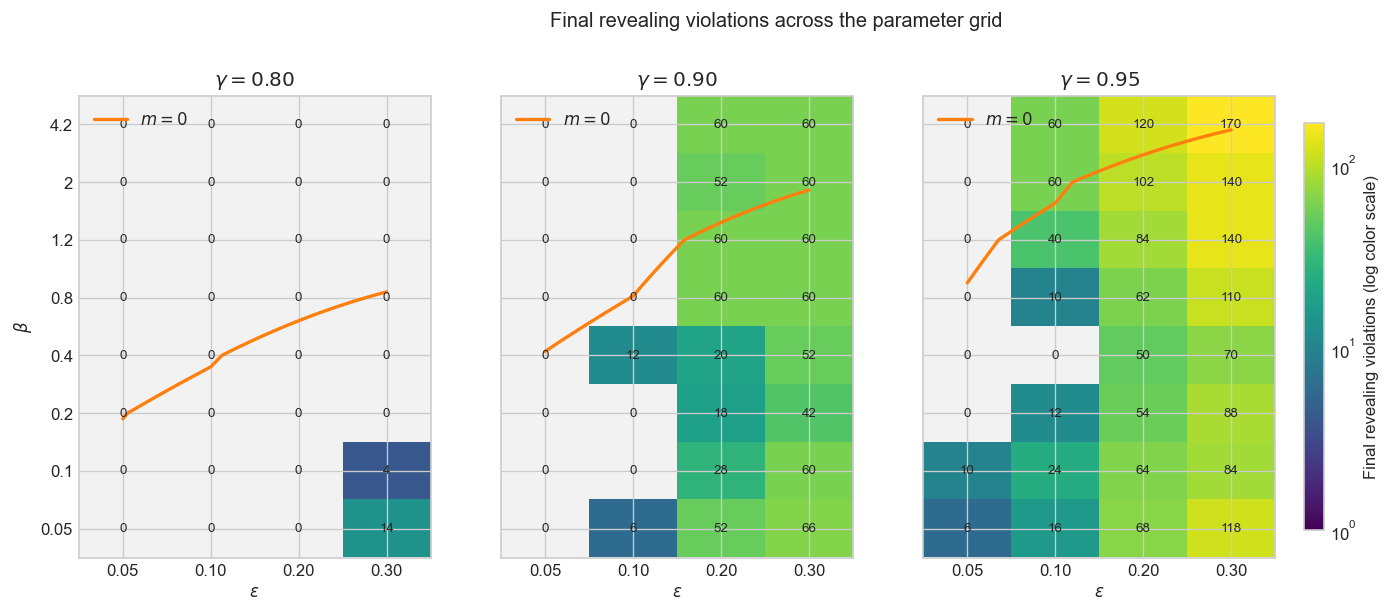

In [8]:
max_count = max(1.000001, float(df.violation_count.max()))
heat_norm = LogNorm(vmin=1, vmax=max_count)
heat_cmap = plt.get_cmap("viridis").copy()
heat_cmap.set_bad("#f2f2f2")

fig, axes = plt.subplots(1, len(GAMMAS), figsize=(15.5, 5.0), sharex=True, sharey=True)
last_mesh = None
for ax, gamma in zip(axes, GAMMAS):
    subset = df[np.isclose(df.gamma, gamma)]
    table = subset.pivot(index="beta", columns="epsilon", values="violation_count")
    table = table.reindex(index=BETAS, columns=EPSILONS)
    values = table.to_numpy(dtype=float)
    masked = np.ma.masked_where(values == 0, values)
    last_mesh = ax.imshow(
        masked, origin="lower", aspect="auto",
        cmap=heat_cmap, norm=heat_norm,
    )
    for row, beta in enumerate(BETAS):
        for column, epsilon in enumerate(EPSILONS):
            ax.text(
                column, row, str(int(values[row, column])),
                ha="center", va="center", fontsize=8,
            )
    epsilon_line = np.linspace(EPSILONS.min(), EPSILONS.max(), 250)
    beta_boundary = gamma * epsilon_line * (1.0 - epsilon_line) / (1.0 - gamma)
    visible = (beta_boundary >= BETAS.min()) & (beta_boundary <= BETAS.max())
    epsilon_positions = np.interp(epsilon_line, EPSILONS, np.arange(len(EPSILONS)))
    beta_positions = np.interp(beta_boundary, BETAS, np.arange(len(BETAS)))
    ax.plot(
        epsilon_positions[visible], beta_positions[visible], color="tab:orange",
        linewidth=2.0, label="$m=0$",
    )
    ax.set_title(rf"$\gamma={gamma:.2f}$")
    ax.set_xlabel(r"$\epsilon$")
    ax.set_xticks(np.arange(len(EPSILONS)), [f"{value:.2f}" for value in EPSILONS])
    ax.set_yticks(np.arange(len(BETAS)), [f"{value:g}" for value in BETAS])
    ax.legend(loc="upper left")
axes[0].set_ylabel(r"$\beta$")
if last_mesh is not None and df.violation_count.max() > 0:
    colorbar = fig.colorbar(last_mesh, ax=axes, shrink=0.88, pad=0.02)
    colorbar.set_label("Final revealing violations (log color scale)")
fig.suptitle("Final revealing violations across the parameter grid", y=1.02)
plt.show()


## Violations as a function of theorem margin


notebook_cell_15:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


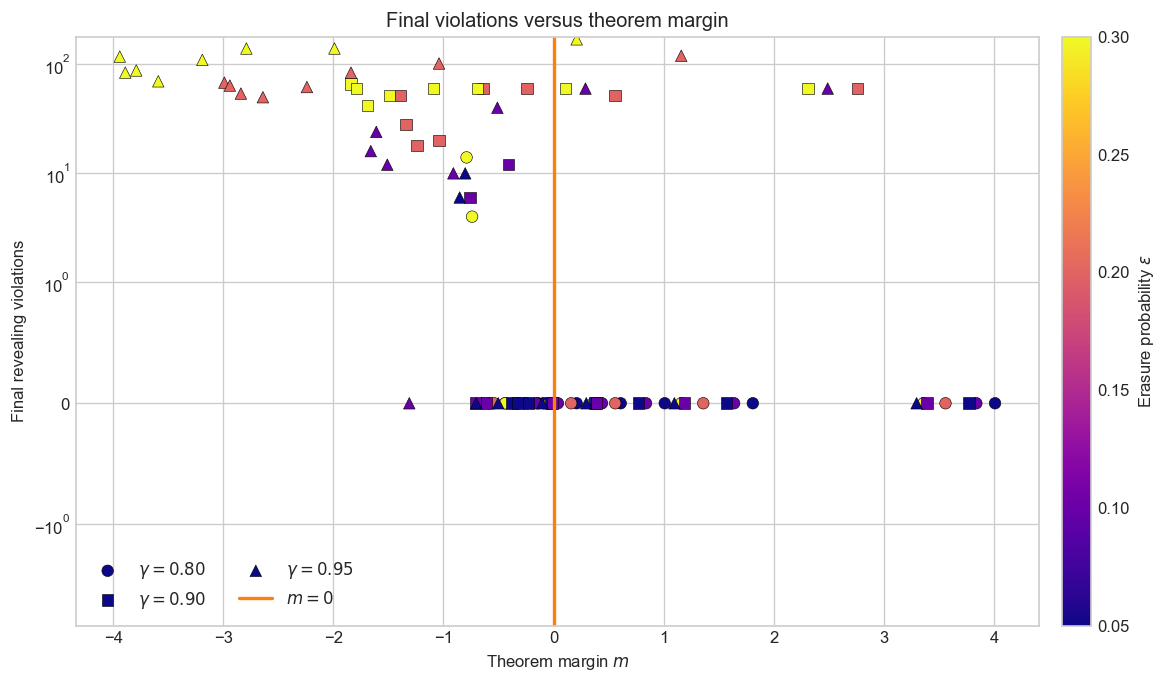

In [9]:
fig, ax = plt.subplots(figsize=(10.5, 5.8))
markers = {0.80: "o", 0.90: "s", 0.95: "^"}
epsilon_norm = Normalize(vmin=float(EPSILONS.min()), vmax=float(EPSILONS.max()))
for gamma in GAMMAS:
    subset = df[np.isclose(df.gamma, gamma)]
    scatter = ax.scatter(
        subset.margin, subset.violation_count,
        c=subset.epsilon, cmap="plasma", norm=epsilon_norm,
        marker=markers[float(gamma)], s=48,
        edgecolors="black", linewidths=0.35,
        label=rf"$\gamma={gamma:.2f}$",
    )
ax.axvline(0.0, color="tab:orange", linewidth=2.0, label="$m=0$")
ax.set_yscale("symlog", linthresh=1)
ax.set_xlabel(r"Theorem margin $m$")
ax.set_ylabel("Final revealing violations")
ax.set_title("Final violations versus theorem margin")
ax.legend(ncol=2)
colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
colorbar.set_label(r"Erasure probability $\epsilon$")
plt.tight_layout()
plt.show()


## Representative API training curves

Runs are selected deterministically: largest final count, nearest margin below zero, nearest margin above zero, and the positive-margin run with the largest temporary count. Duplicate selections are removed.


notebook_cell_17:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


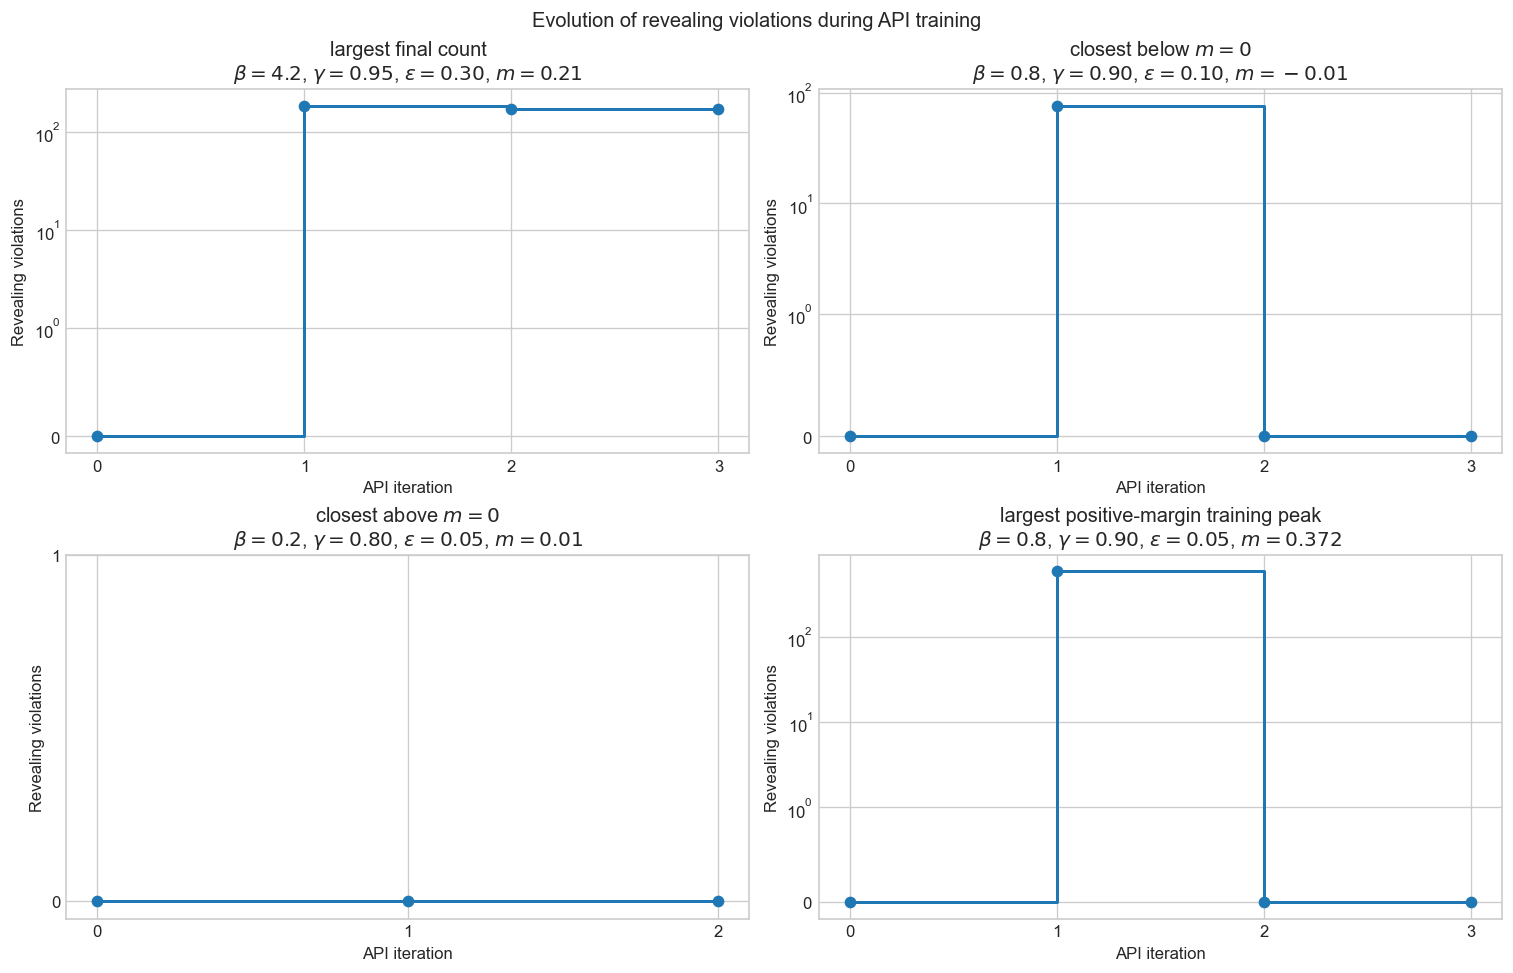

In [10]:
selections: list[tuple[str, pd.Series]] = []
selections.append(("largest final count", df.loc[df.violation_count.idxmax()]))
negative = df[df.margin < -MARGIN_TOL]
positive_margin = df[df.margin > MARGIN_TOL]
if not negative.empty:
    selections.append(("closest below $m=0$", negative.loc[negative.margin.idxmax()]))
if not positive_margin.empty:
    selections.append(("closest above $m=0$", positive_margin.loc[positive_margin.margin.idxmin()]))
    selections.append((
        "largest positive-margin training peak",
        positive_margin.loc[positive_margin.peak_training_violations.idxmax()],
    ))

unique_selections: list[tuple[str, pd.Series]] = []
seen_keys: set[str] = set()
for reason, row in selections:
    if row.key not in seen_keys:
        unique_selections.append((reason, row))
        seen_keys.add(row.key)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.0), constrained_layout=True)
for ax, (reason, row) in zip(axes.flat, unique_selections):
    history = row.violation_history
    iterations = [item["api_iteration"] for item in history]
    counts = [item["violation_count"] for item in history]
    ax.step(iterations, counts, where="post", marker="o", linewidth=1.8)
    if max(counts) > 0:
        ax.set_yscale("symlog", linthresh=1)
    else:
        ax.set_ylim(-0.05, 1.0)
        ax.set_yticks([0, 1])
    ax.set_xlabel("API iteration")
    ax.set_ylabel("Revealing violations")
    ax.set_title(
        f"{reason}\n"
        + rf"$\beta={row.beta:.2g}$, $\gamma={row.gamma:.2f}$, "
          rf"$\epsilon={row.epsilon:.2f}$, $m={row.margin:.3g}$"
    )
    ax.set_xticks(iterations)
for ax in axes.flat[len(unique_selections):]:
    ax.remove()
fig.suptitle("Evolution of revealing violations during API training")
plt.show()


## API stopping tolerance relative to the theorem margin

The vertical coordinate is api_tol / |m|. A value at or above one means that the configured objective-improvement stopping scale is at least as large as the distance to the theoretical boundary. A value above 0.1 is within one order of magnitude. Filled red points are runs with final revealing violations; hollow points have none. This is a numerical-resolution diagnostic, not a theorem guarantee.


notebook_cell_19:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
Points with api_tol >= |m|: 0
Largest api_tol / |m| ratio: 1.000e-07


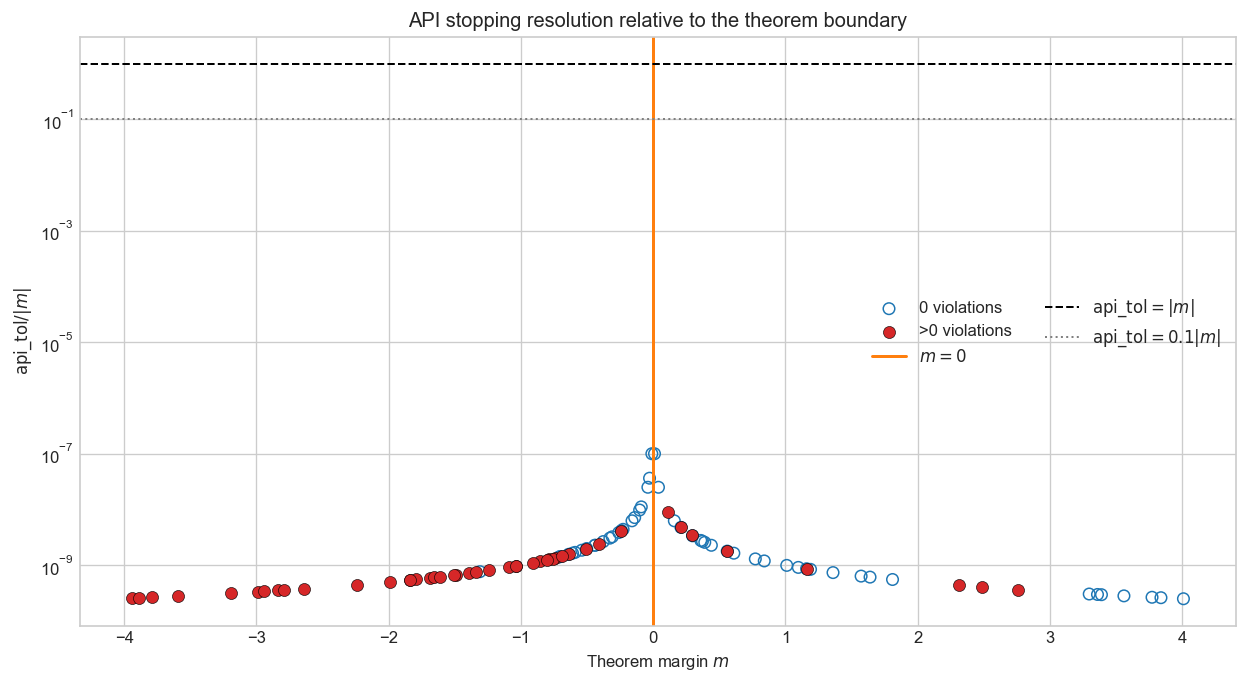

In [11]:
comparable = df[np.abs(df.margin) > MARGIN_TOL].copy()
without_violations = comparable[comparable.violation_count == 0]
with_violations = comparable[comparable.violation_count > 0]

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.scatter(
    without_violations.margin, without_violations.api_margin_ratio,
    facecolors="none", edgecolors="tab:blue",
    s=48, linewidths=0.9, label="0 violations",
)
ax.scatter(
    with_violations.margin, with_violations.api_margin_ratio,
    color="tab:red", edgecolors="black",
    s=52, linewidths=0.35, label=">0 violations",
)
ax.axvline(0.0, color="tab:orange", linewidth=1.8, label="$m=0$")
ax.axhline(
    1.0, color="black", linestyle="--", linewidth=1.2,
    label=r"$\mathrm{api\_tol}=|m|$",
)
ax.axhline(
    0.1, color="gray", linestyle=":", linewidth=1.2,
    label=r"$\mathrm{api\_tol}=0.1|m|$",
)
ax.set_yscale("log")
ax.set_xlabel(r"Theorem margin $m$")
ax.set_ylabel(r"$\mathrm{api\_tol}/|m|$")
ax.set_title("API stopping resolution relative to the theorem boundary")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

numerically_unresolved = comparable[comparable.api_margin_ratio >= 1.0]
print(f"Points with api_tol >= |m|: {len(numerically_unresolved)}")
print(f"Largest api_tol / |m| ratio: {comparable.api_margin_ratio.max():.3e}")


## Computed summary


In [12]:
positive_region = df[df.margin > MARGIN_TOL]
negative_region = df[df.margin < -MARGIN_TOL]
boundary_region = df[np.abs(df.margin) <= MARGIN_TOL]

summary = {
    "successful_runs": len(df),
    "failed_runs": len(failed_runs),
    "positive_margin_runs": len(positive_region),
    "positive_margin_runs_with_violations": int((positive_region.violation_count > 0).sum()),
    "negative_margin_runs": len(negative_region),
    "negative_margin_runs_with_violations": int((negative_region.violation_count > 0).sum()),
    "boundary_margin_runs": len(boundary_region),
    "maximum_final_violation_count": int(df.violation_count.max()),
    "maximum_training_violation_count": int(df.peak_training_violations.max()),
    "api_converged_runs": int(df.api_converged.sum()),
    "approximate_restricted_ne_runs": int(df.approximate_restricted_ne.sum()),
    "maximum_restricted_regret": float(df.max_restricted_regret.max()),
    "api_tolerance_not_smaller_than_abs_margin": int((df.api_margin_ratio >= 1.0).sum()),
}
print(json.dumps(summary, indent=2))


{
  "successful_runs": 96,
  "failed_runs": 0,
  "positive_margin_runs": 36,
  "positive_margin_runs_with_violations": 8,
  "negative_margin_runs": 60,
  "negative_margin_runs_with_violations": 37,
  "boundary_margin_runs": 0,
  "maximum_final_violation_count": 170,
  "maximum_training_violation_count": 638,
  "api_converged_runs": 96,
  "approximate_restricted_ne_runs": 96,
  "maximum_restricted_regret": 0.0,
  "api_tolerance_not_smaller_than_abs_margin": 0
}
